# India's Contribution to GBIF Citizen Science Data
## Analysis for Nature India

Prepared for a Nature India journalist interview (Sahana Ghosh). This notebook analyzes India's vascular plant occurrence records in the Global Biodiversity Information Facility (GBIF) database (DOI: [10.15468/dl.mvrs2b](https://doi.org/10.15468/dl.mvrs2b)), which contains ~314M georeferenced tracheophyte records globally.

**Key questions:**
1. What is India's relative contribution to GBIF, normalized by population, area, and biodiversity?
2. Which regions/cities within India contribute the most?
3. What biases exist in Indian citizen science data?
4. How does India's data connect to global trait mapping?

In [5]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit
from pathlib import Path

sns.set_theme(context="paper", style="ticks", font_scale=1.4)
plt.rcParams["figure.dpi"] = 150

PARQUET_PATH = "../data/raw/all_tracheophyta_non-cult/0061405-250920141307145.parquet/*"

# iNaturalist Research-grade Observations dataset key
INAT_DATASET_KEY = "50c9509d-22c7-4a22-a47d-8c48425ef4a7"

In [6]:
# Reference data for normalization
# Sources: World Bank 2023 (population, area), Kew State of the World's Plants / national floras (species richness)
COUNTRY_REF = pd.DataFrame({
    "countrycode": [
        "FR", "GB", "DE", "NL", "US", "AU", "SE", "ES", "DK", "CH",
        "IN", "CN", "BR", "ZA", "MX", "CO", "JP", "NZ", "NO", "FI",
        "PK", "BD", "LK", "NP", "BT", "MM",
    ],
    "country_name": [
        "France", "UK", "Germany", "Netherlands", "USA", "Australia",
        "Sweden", "Spain", "Denmark", "Switzerland",
        "India", "China", "Brazil", "South Africa", "Mexico", "Colombia",
        "Japan", "New Zealand", "Norway", "Finland",
        "Pakistan", "Bangladesh", "Sri Lanka", "Nepal", "Bhutan", "Myanmar",
    ],
    "population_m": [
        68.2, 67.7, 84.5, 17.9, 339.9, 26.6, 10.5, 48.1, 5.9, 8.8,
        1428.6, 1425.7, 216.4, 60.4, 128.9, 52.1, 125.1, 5.2, 5.5, 5.6,
        240.5, 172.9, 22.2, 30.9, 0.8, 54.8,
    ],
    "area_mkm2": [
        0.640, 0.244, 0.357, 0.042, 9.834, 7.692, 0.450, 0.506, 0.043, 0.041,
        3.287, 9.597, 8.516, 1.221, 1.964, 1.142, 0.378, 0.268, 0.385, 0.338,
        0.881, 0.148, 0.066, 0.147, 0.038, 0.677,
    ],
    "est_plant_species": [
        6000, 3300, 4100, 2200, 19500, 21000, 2600, 7500, 1900, 3600,
        18000, 33000, 33000, 21000, 26000, 27000, 7000, 2400, 3200, 1600,
        6000, 5000, 3500, 7000, 5600, 11000,
    ],
}).set_index("countrycode")

# Major Indian cities for spatial proximity analysis
INDIA_CITIES = pd.DataFrame({
    "city": [
        "Mumbai", "Delhi", "Bengaluru", "Chennai", "Kolkata", "Hyderabad",
        "Pune", "Ahmedabad", "Jaipur", "Lucknow", "Kochi", "Guwahati",
        "Chandigarh", "Bhopal", "Dehradun", "Thiruvananthapuram",
    ],
    "lat": [
        19.08, 28.61, 12.97, 13.08, 22.57, 17.39,
        18.52, 23.02, 26.91, 26.85, 9.93, 26.14,
        30.73, 23.26, 30.32, 8.52,
    ],
    "lon": [
        72.88, 77.21, 77.59, 80.27, 88.36, 78.49,
        73.86, 72.57, 75.79, 80.95, 76.27, 91.74,
        76.78, 77.41, 78.03, 76.94,
    ],
})

## 1. Data Loading

In [8]:
# Global scan: load only countrycode to get country-level record counts
global_country_counts = (
    dd.read_parquet(PARQUET_PATH, columns=["countrycode"])
    ["countrycode"]
    .value_counts()
    .compute()
    .sort_values(ascending=False)
    .rename("n_records")
)

total_global = global_country_counts.sum()
print(f"Total global records: {total_global:,}")
print(f"Number of countries: {len(global_country_counts)}")
print(f"\nIndia (IN): {global_country_counts.get('IN', 0):,} records")
print(f"India's share: {global_country_counts.get('IN', 0) / total_global:.4%}")
print(f"\nTop 10 countries:")
for cc, n in global_country_counts.head(10).items():
    print(f"  {cc}: {n:,}")

Total global records: 314,644,916
Number of countries: 249

India (IN): 200,175 records
India's share: 0.0636%

Top 10 countries:
  FR: 71,030,169
  SE: 32,864,971
  GB: 27,719,916
  US: 20,265,969
  AU: 19,913,966
  NL: 18,028,571
  DE: 15,104,474
  CH: 15,031,124
  DK: 14,338,390
  BE: 12,212,275


In [9]:
# Load full India subset
INDIA_COLS = [
    "countrycode", "stateprovince", "basisofrecord",
    "year", "month",
    "publishingorgkey", "datasetkey", "institutioncode",
    "species", "specieskey",
    "decimallatitude", "decimallongitude",
    "coordinateuncertaintyinmeters",
    "family", "genus", "taxonrank",
]

india_df = (
    dd.read_parquet(PARQUET_PATH, columns=INDIA_COLS)
    .query("countrycode == 'IN'")
    .compute()
)

print(f"India records loaded: {len(india_df):,}")
india_df.head(3)

India records loaded: 200,175


,countrycode,stateprovince,basisofrecord,year,month,publishingorgkey,datasetkey,institutioncode,species,specieskey,decimallatitude,decimallongitude,coordinateuncertaintyinmeters,family,genus,taxonrank
3244,IN,Delhi,PRESERVED_SPECIMEN,1957.0,10.0,814cdfb5-d4f8-4453-815f-ea5df98e76bf,e05fd4c2-4d77-4c50-880e-1b22096af300,ASU,Ammi majus,3034182,28.584252,77.161639,500.0,Apiaceae,Ammi,SPECIES
11105,IN,<NA>,PRESERVED_SPECIMEN,NaN,NaN,814cdfb5-d4f8-4453-815f-ea5df98e76bf,e05fd4c2-4d77-4c50-880e-1b22096af300,ASU,Gamochaeta pensylvanica,3103082,28.666000,77.100000,301.0,Asteraceae,Gamochaeta,SPECIES
16537,IN,Delhi,PRESERVED_SPECIMEN,1970.0,11.0,814cdfb5-d4f8-4453-815f-ea5df98e76bf,e05fd4c2-4d77-4c50-880e-1b22096af300,ASU,Foeniculum vulgare,3034922,28.586420,77.162560,600.0,Apiaceae,Foeniculum,SPECIES


## 2. India's Relative Contribution to GBIF

How does India compare to other countries, both in absolute terms and when normalized by population, land area, and known biodiversity?

In [10]:
# Build comparison table
comparison = (
    COUNTRY_REF
    .join(global_country_counts, how="inner")
    .assign(
        records_per_million_pop=lambda x: x.n_records / x.population_m,
        records_per_mkm2=lambda x: x.n_records / x.area_mkm2,
        records_per_species=lambda x: x.n_records / x.est_plant_species,
    )
)

india_row = comparison.loc["IN"]
print("=== India's GBIF Rankings (among 26 reference countries) ===")
for metric, label in [
    ("n_records", "Absolute records"),
    ("records_per_million_pop", "Per million population"),
    ("records_per_mkm2", "Per million km²"),
    ("records_per_species", "Per known species"),
]:
    rank = (comparison[metric] > india_row[metric]).sum() + 1
    print(f"  {label}: {india_row[metric]:,.0f} (rank {rank}/{len(comparison)})")

=== India's GBIF Rankings (among 26 reference countries) ===
  Absolute records: 200,175 (rank 19/26)
  Per million population: 140 (rank 22/26)
  Per million km²: 60,899 (rank 21/26)
  Per known species: 11 (rank 18/26)


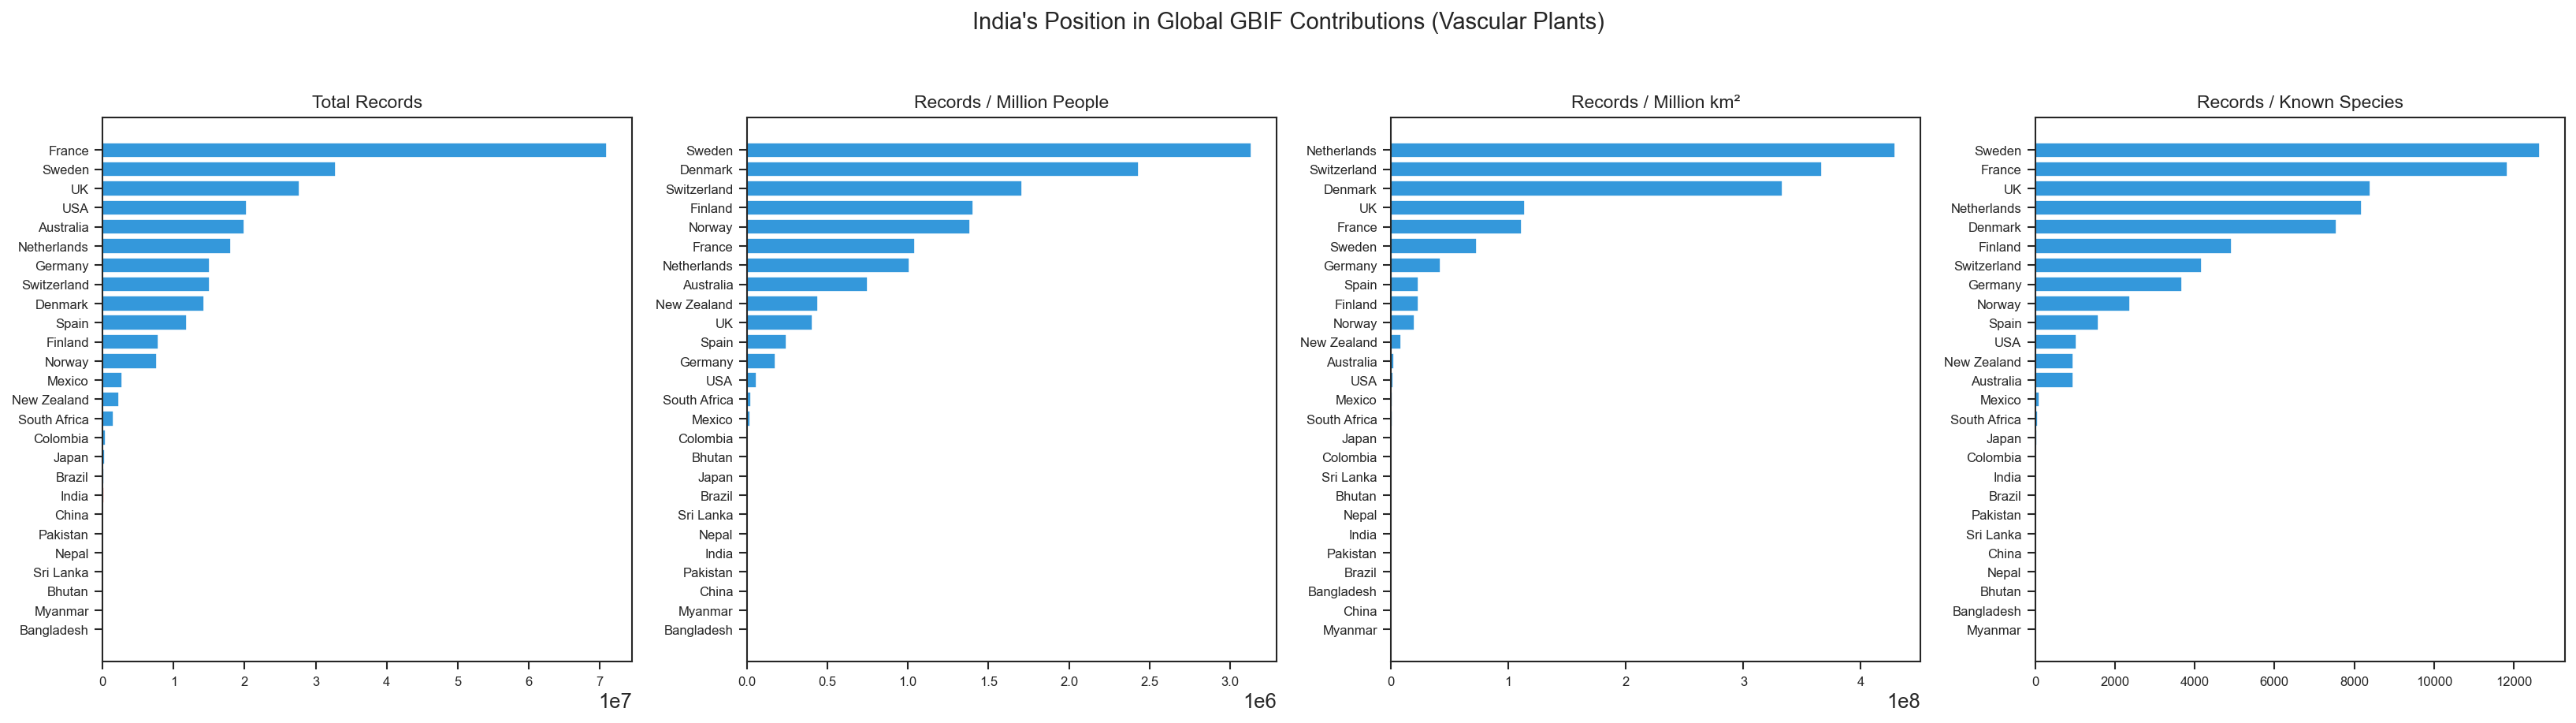

In [11]:
# Figure 1: 4-panel global ranking
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
metrics = [
    ("n_records", "Total Records"),
    ("records_per_million_pop", "Records / Million People"),
    ("records_per_mkm2", "Records / Million km²"),
    ("records_per_species", "Records / Known Species"),
]

for ax, (col, title) in zip(axes, metrics):
    data = comparison.sort_values(col, ascending=True)
    colors = ["#e74c3c" if idx == "IN" else "#3498db" for idx in data.index]
    ax.barh(data.country_name, data[col], color=colors)
    ax.set_title(title, fontsize=11)
    ax.tick_params(labelsize=8)

fig.suptitle(
    "India's Position in Global GBIF Contributions (Vascular Plants)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

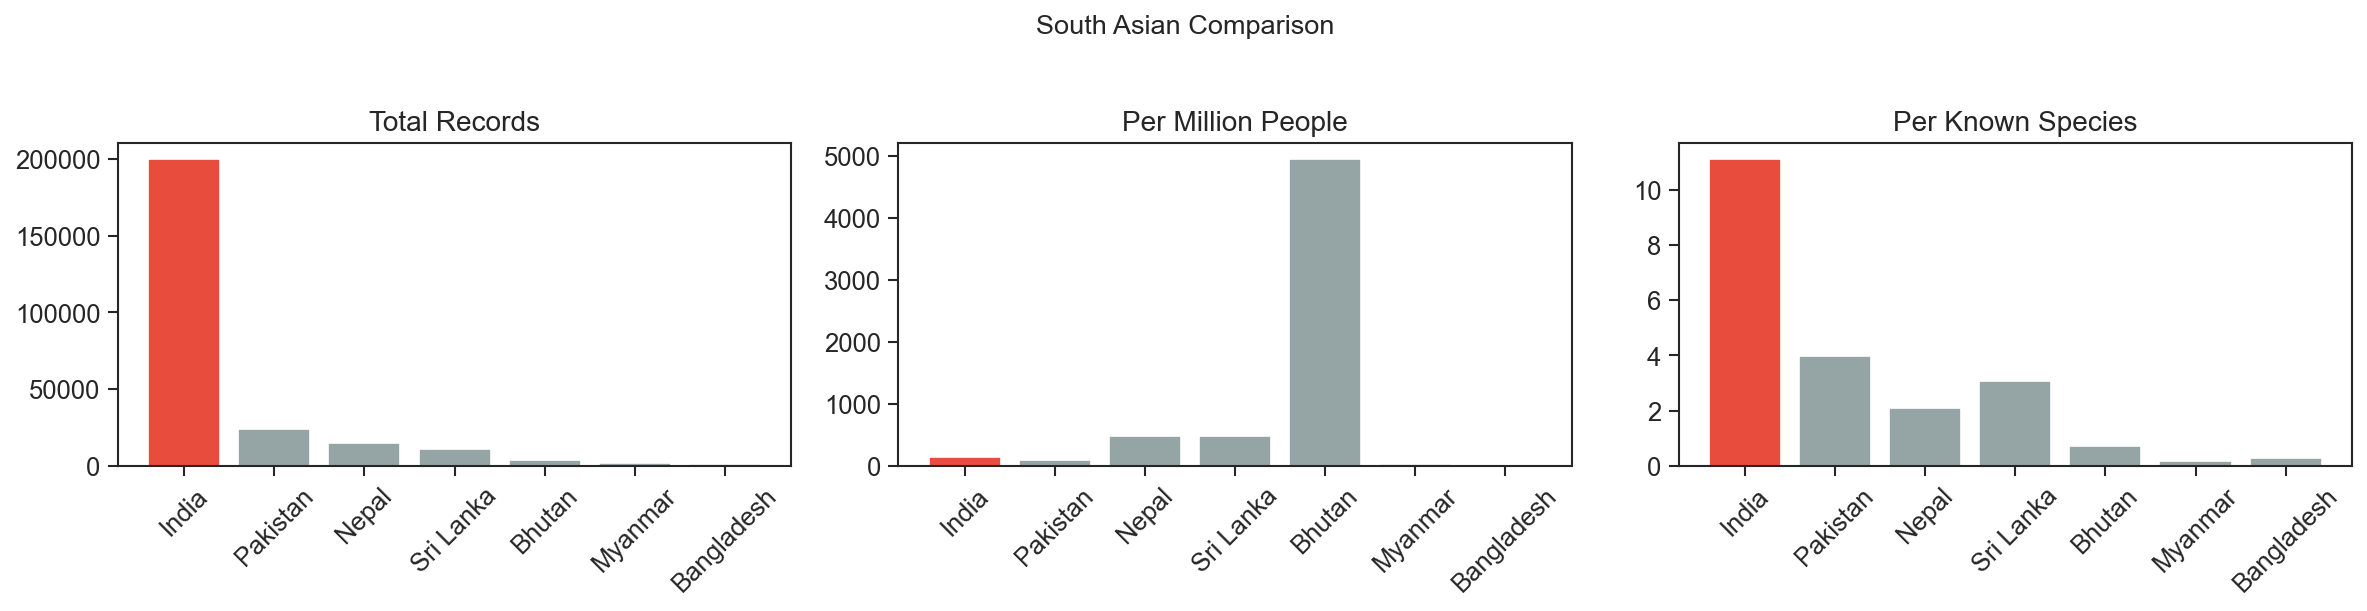

In [12]:
# Figure 2: South Asian comparison
south_asia_codes = ["IN", "PK", "BD", "LK", "NP", "BT", "MM"]
sa_comp = comparison.loc[comparison.index.isin(south_asia_codes)].sort_values(
    "n_records", ascending=False
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (col, title) in zip(
    axes,
    [
        ("n_records", "Total Records"),
        ("records_per_million_pop", "Per Million People"),
        ("records_per_species", "Per Known Species"),
    ],
):
    colors = [
        "#e74c3c" if c == "IN" else "#95a5a6" for c in sa_comp.index
    ]
    ax.bar(sa_comp.country_name, sa_comp[col], color=colors)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("South Asian Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [13]:
# Journalist-friendly summary
print("KEY FINDINGS — India's Relative Contribution")
print("=" * 55)
print(f"- India has {india_row.n_records:,.0f} vascular plant records in GBIF")
print(f"- This is {india_row.n_records / total_global:.2%} of the global total ({total_global:,.0f})")
print(f"- Per capita: {india_row.records_per_million_pop:,.0f} records per million people")
fr_pmp = comparison.loc["FR", "records_per_million_pop"]
us_pmp = comparison.loc["US", "records_per_million_pop"]
print(f"  (compare: France ~{fr_pmp:,.0f}, USA ~{us_pmp:,.0f})")
print(f"- India is a megadiverse country with ~18,000 vascular plant species")
print(f"  but only {india_row.records_per_species:,.1f} GBIF records per species")

KEY FINDINGS — India's Relative Contribution
- India has 200,175 vascular plant records in GBIF
- This is 0.06% of the global total (314,644,916)
- Per capita: 140 records per million people
  (compare: France ~1,041,498, USA ~59,623)
- India is a megadiverse country with ~18,000 vascular plant species
  but only 11.1 GBIF records per species


## 3. Geographic Distribution Within India

Where in India are citizen science observations concentrated?

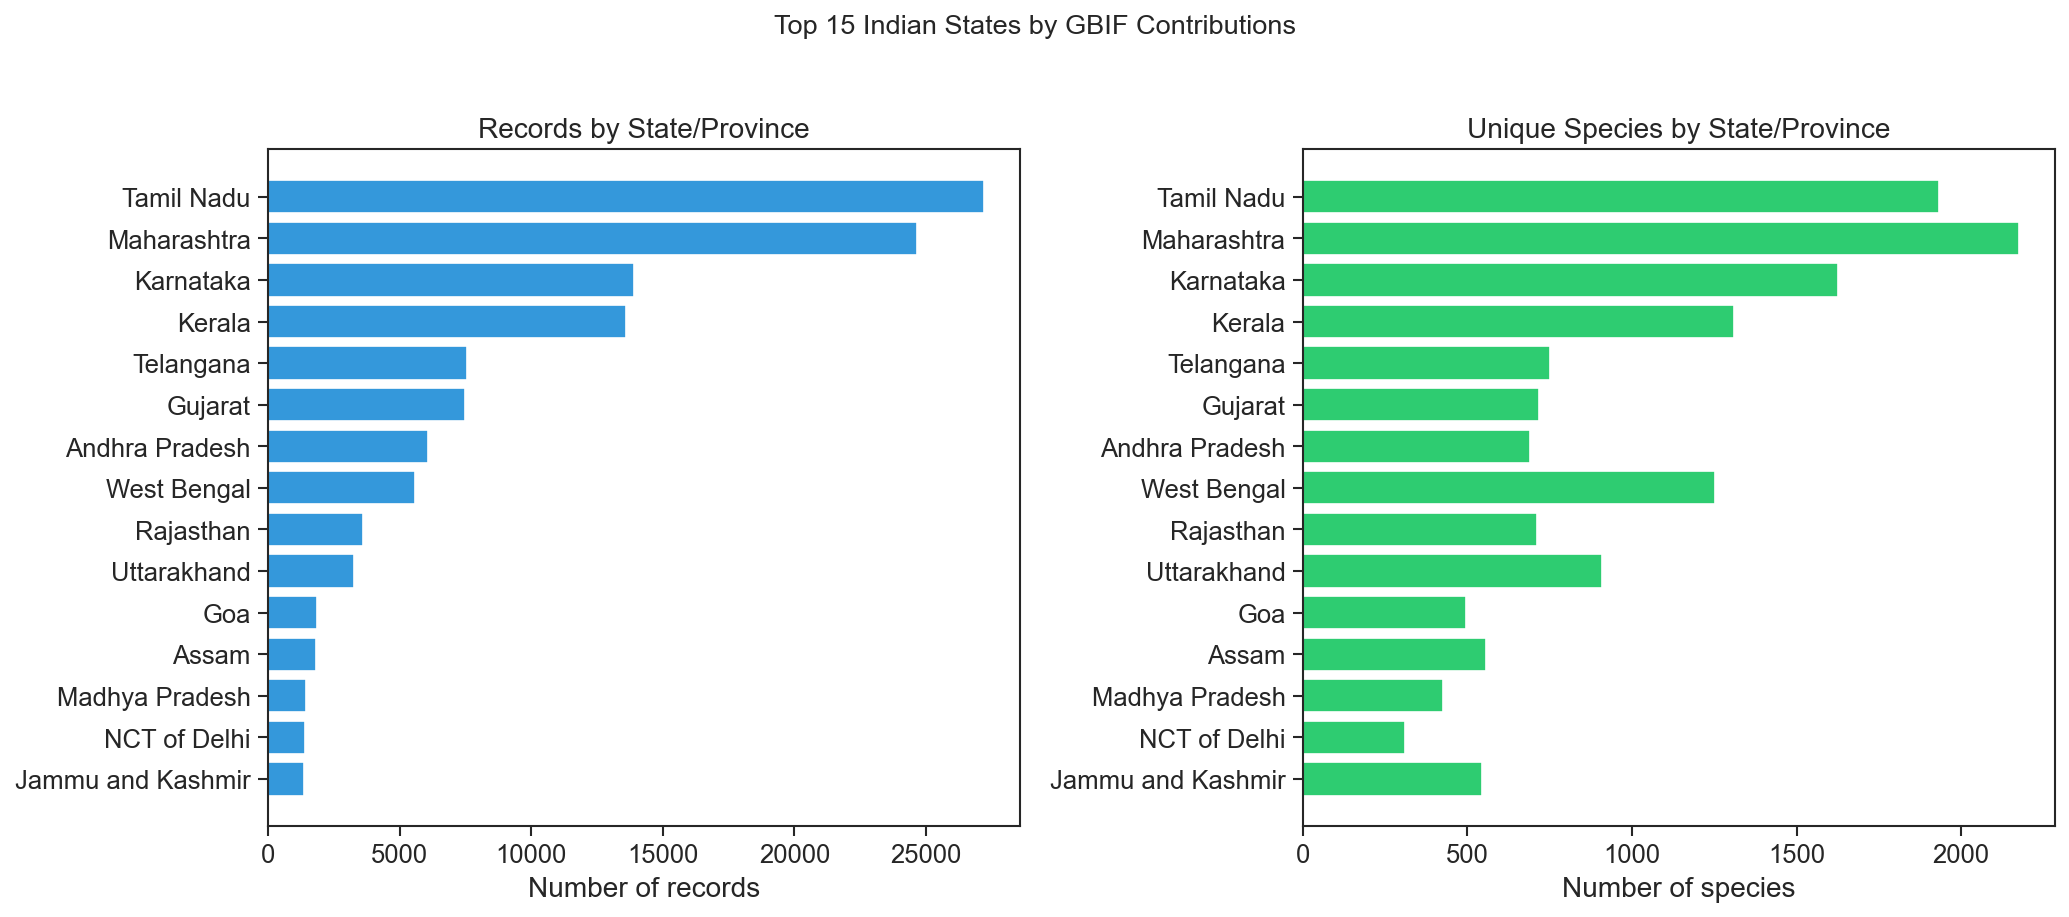

In [14]:
# Figure 3: State-level analysis
state_counts = (
    india_df.groupby("stateprovince")
    .agg(n_records=("species", "size"), n_species=("species", "nunique"))
    .sort_values("n_records", ascending=False)
)

top_states = state_counts.head(15)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_states.index[::-1], top_states.n_records[::-1], color="#3498db")
axes[0].set_title("Records by State/Province")
axes[0].set_xlabel("Number of records")

axes[1].barh(top_states.index[::-1], top_states.n_species[::-1], color="#2ecc71")
axes[1].set_title("Unique Species by State/Province")
axes[1].set_xlabel("Number of species")

fig.suptitle("Top 15 Indian States by GBIF Contributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

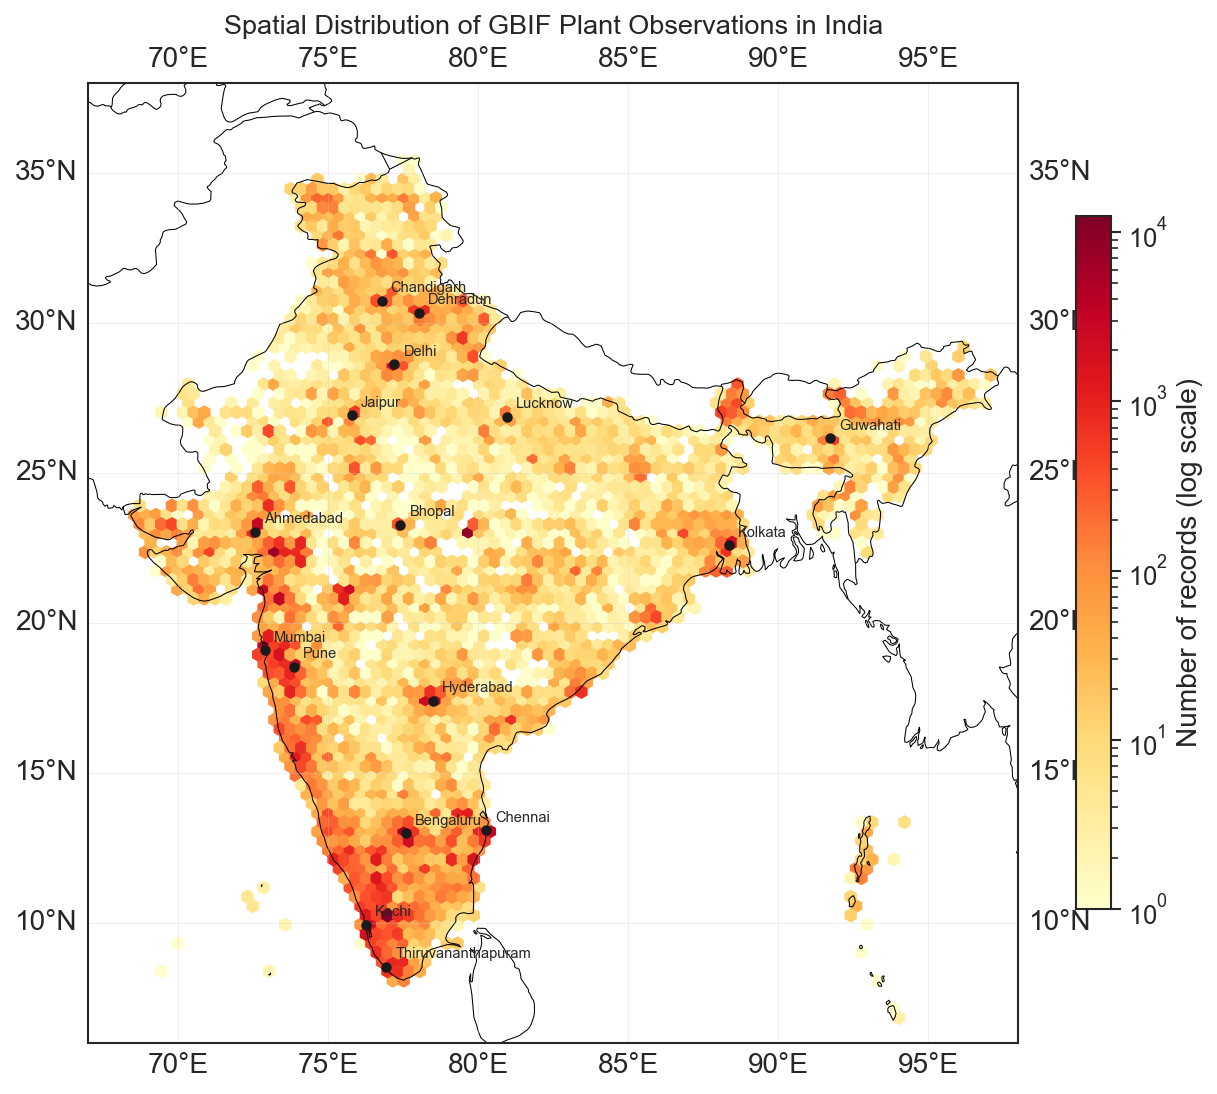

In [15]:
# Figure 4: Spatial density map of India
india_geo = india_df.dropna(subset=["decimallatitude", "decimallongitude"])

fig, ax = plt.subplots(
    figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()}
)

hb = ax.hexbin(
    india_geo.decimallongitude,
    india_geo.decimallatitude,
    gridsize=80,
    bins="log",
    cmap="YlOrRd",
    mincnt=1,
    transform=ccrs.PlateCarree(),
)
ax.set_extent([67, 98, 6, 38], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

# Overlay city markers
for _, city in INDIA_CITIES.iterrows():
    ax.plot(city.lon, city.lat, "ko", markersize=4, transform=ccrs.PlateCarree())
    ax.text(
        city.lon + 0.3, city.lat + 0.3, city.city,
        fontsize=7, transform=ccrs.PlateCarree(),
    )

plt.colorbar(hb, ax=ax, shrink=0.6, label="Number of records (log scale)")
ax.set_title("Spatial Distribution of GBIF Plant Observations in India", fontsize=13)
plt.show()

28.1% of observations are within 50 km of a major city
44.5% of observations are within 100 km of a major city


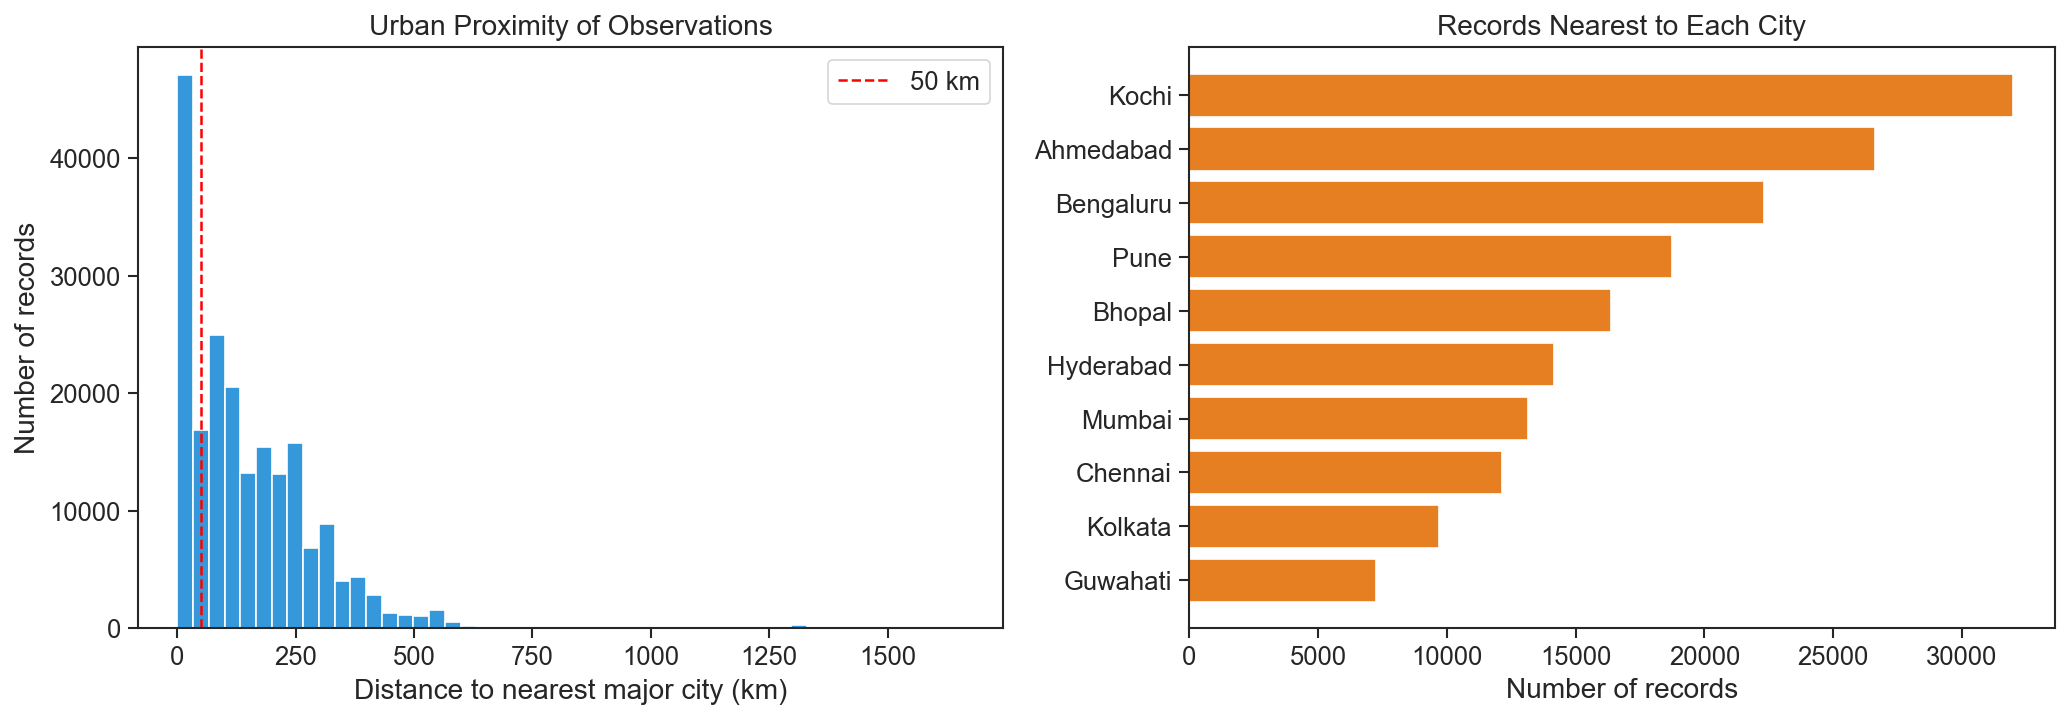

In [16]:
# Figure 5: Urban proximity analysis
city_coords = INDIA_CITIES[["lat", "lon"]].values
tree = cKDTree(city_coords)

obs_coords = india_geo[["decimallatitude", "decimallongitude"]].values
distances_deg, nearest_idx = tree.query(obs_coords)

# ~111 km per degree at India's latitude range — approximate but sufficient
india_geo = india_geo.assign(
    dist_to_city_km=distances_deg * 111,
    nearest_city=INDIA_CITIES.city.values[nearest_idx],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(india_geo.dist_to_city_km, bins=50, color="#3498db", edgecolor="white")
axes[0].set_xlabel("Distance to nearest major city (km)")
axes[0].set_ylabel("Number of records")
axes[0].set_title("Urban Proximity of Observations")
axes[0].axvline(x=50, color="red", linestyle="--", label="50 km")
axes[0].legend()

city_agg = india_geo.nearest_city.value_counts().head(10)
axes[1].barh(city_agg.index[::-1], city_agg.values[::-1], color="#e67e22")
axes[1].set_title("Records Nearest to Each City")
axes[1].set_xlabel("Number of records")

pct_within_50km = (india_geo.dist_to_city_km < 50).mean()
pct_within_100km = (india_geo.dist_to_city_km < 100).mean()
print(f"{pct_within_50km:.1%} of observations are within 50 km of a major city")
print(f"{pct_within_100km:.1%} of observations are within 100 km of a major city")

plt.tight_layout()
plt.show()

In [17]:
# Coverage gap analysis
india_geo = india_geo.assign(
    lat_bin=np.round(india_geo.decimallatitude * 2) / 2,
    lon_bin=np.round(india_geo.decimallongitude * 2) / 2,
)
sampled_cells = india_geo.groupby(["lat_bin", "lon_bin"]).size().reset_index(name="count")

print(f"0.5-degree grid cells with >= 1 observation: {len(sampled_cells)}")
print(f"Cells with >= 10 observations: {(sampled_cells['count'] >= 10).sum()}")
print(f"Cells with >= 100 observations: {(sampled_cells['count'] >= 100).sum()}")

0.5-degree grid cells with >= 1 observation: 1227
Cells with >= 10 observations: 882
Cells with >= 100 observations: 251


## 4. Biases in Indian Citizen Science Data

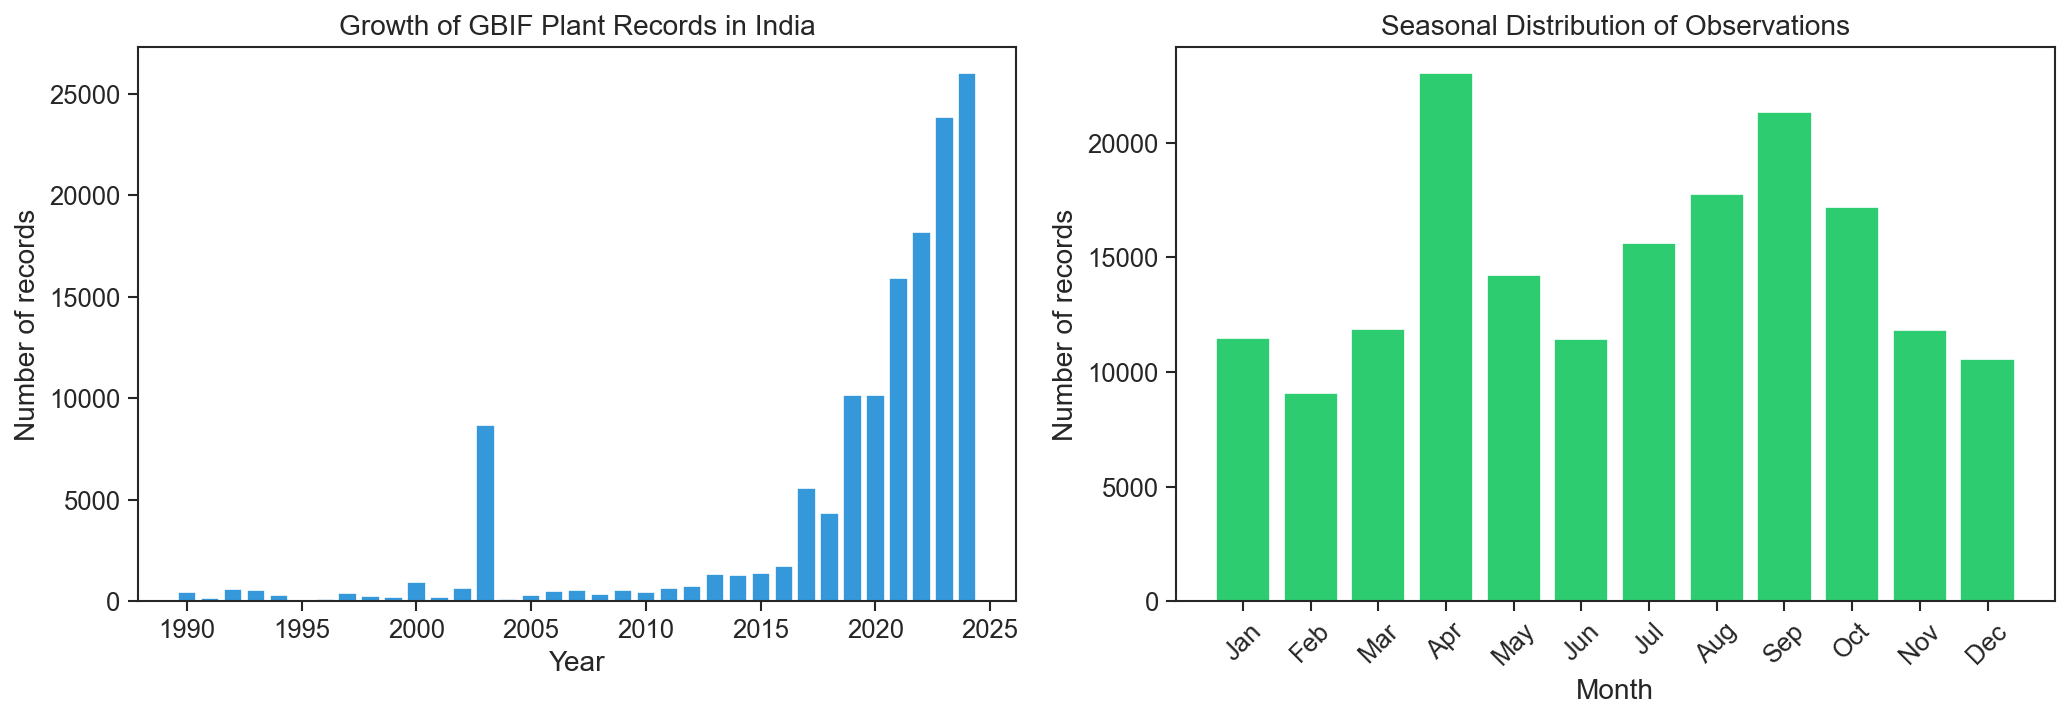

Compound annual growth rate (2019-2024): 20.7%


In [18]:
# Figure 6: Temporal patterns — annual growth + seasonality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_counts = india_df.dropna(subset=["year"]).query("1990 <= year <= 2024").groupby("year").size()
axes[0].bar(year_counts.index.astype(int), year_counts.values, color="#3498db")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of records")
axes[0].set_title("Growth of GBIF Plant Records in India")

month_counts = india_df.dropna(subset=["month"]).groupby("month").size()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
axes[1].bar(
    range(1, 13),
    [month_counts.get(float(m), 0) for m in range(1, 13)],
    color="#2ecc71",
    tick_label=month_names,
)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of records")
axes[1].set_title("Seasonal Distribution of Observations")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Growth rate
recent = year_counts.loc[2019:2024]
if len(recent) >= 2:
    growth = (recent.iloc[-1] / recent.iloc[0]) ** (1 / (len(recent) - 1)) - 1
    print(f"Compound annual growth rate (2019-2024): {growth:.1%}")

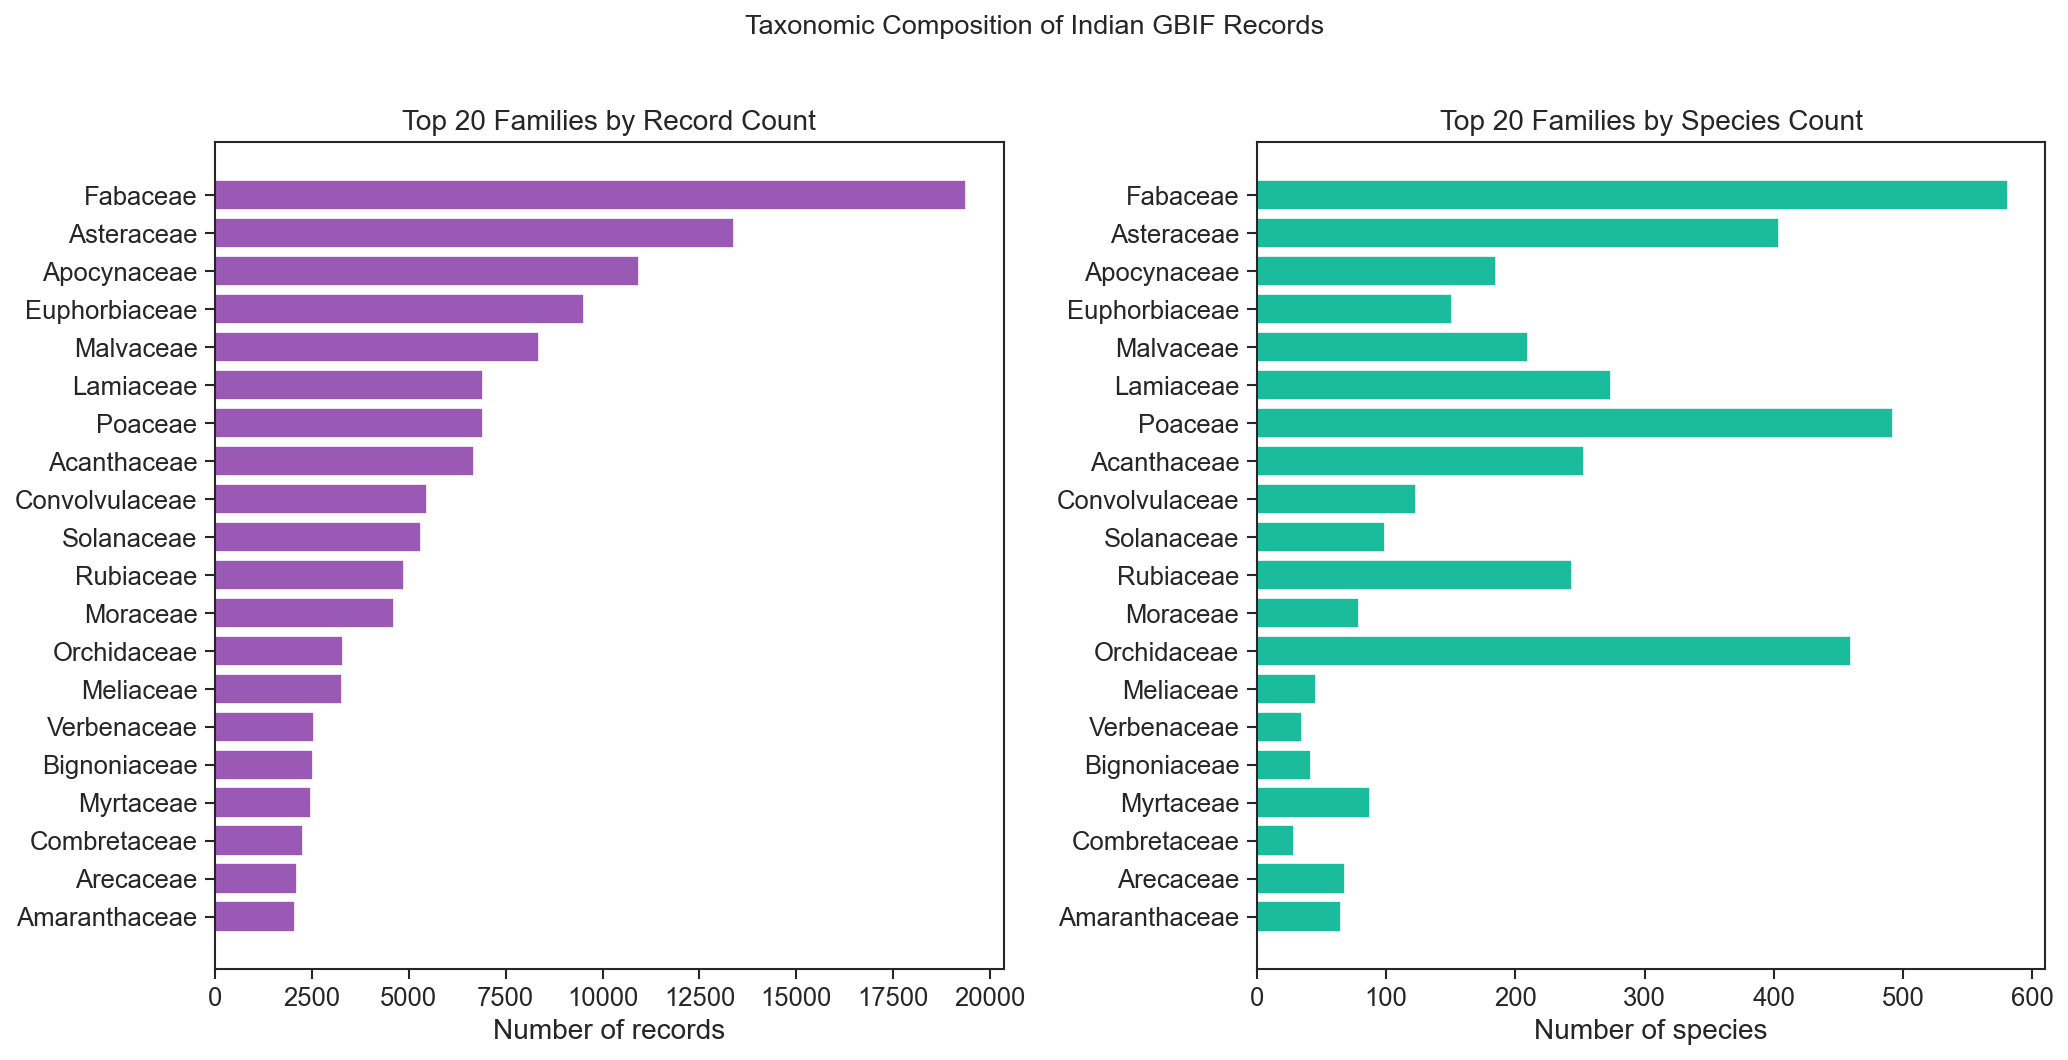

Top 5 families account for 30.8% of all records


In [19]:
# Figure 7: Taxonomic composition — top 20 families
family_counts = (
    india_df.groupby("family")
    .agg(n_records=("species", "size"), n_species=("species", "nunique"))
    .sort_values("n_records", ascending=False)
)

top_fam = family_counts.head(20)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(top_fam.index[::-1], top_fam.n_records[::-1], color="#9b59b6")
axes[0].set_title("Top 20 Families by Record Count")
axes[0].set_xlabel("Number of records")

axes[1].barh(top_fam.index[::-1], top_fam.n_species[::-1], color="#1abc9c")
axes[1].set_title("Top 20 Families by Species Count")
axes[1].set_xlabel("Number of species")

fig.suptitle("Taxonomic Composition of Indian GBIF Records", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

top5_pct = family_counts.n_records.head(5).sum() / family_counts.n_records.sum()
print(f"Top 5 families account for {top5_pct:.1%} of all records")

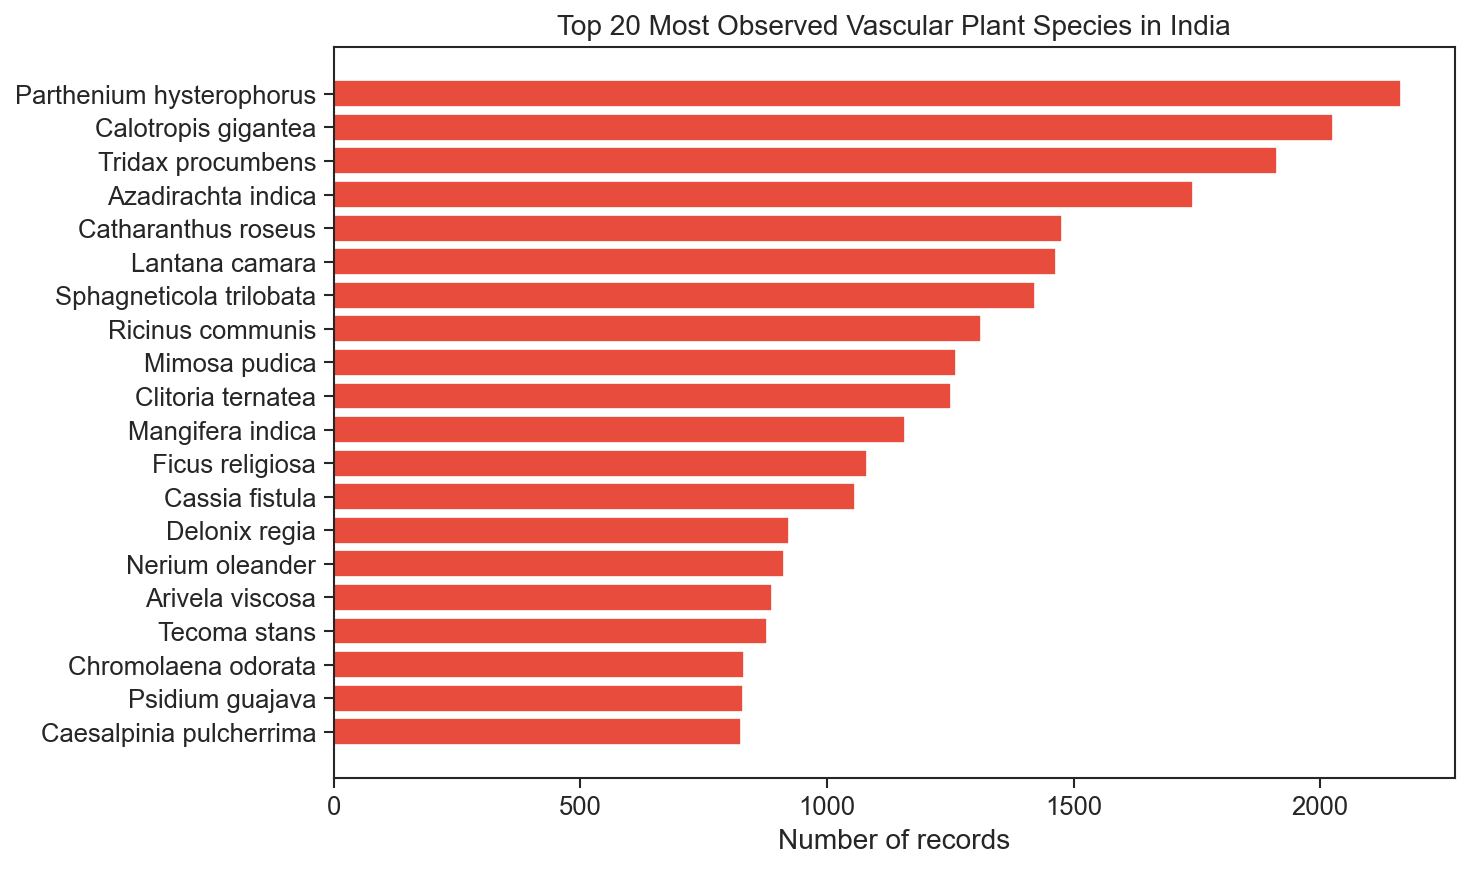

Total unique species observed: 8,148
Top 20 species account for 12.7% of records


In [20]:
# Figure 8: Top 20 most-observed species
species_counts = india_df.groupby("species").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top20_sp = species_counts.head(20)
ax.barh(top20_sp.index[::-1], top20_sp.values[::-1], color="#e74c3c")
ax.set_xlabel("Number of records")
ax.set_title("Top 20 Most Observed Vascular Plant Species in India")
plt.tight_layout()
plt.show()

total_species = india_df.species.nunique()
print(f"Total unique species observed: {total_species:,}")
print(f"Top 20 species account for {top20_sp.sum() / len(india_df):.1%} of records")

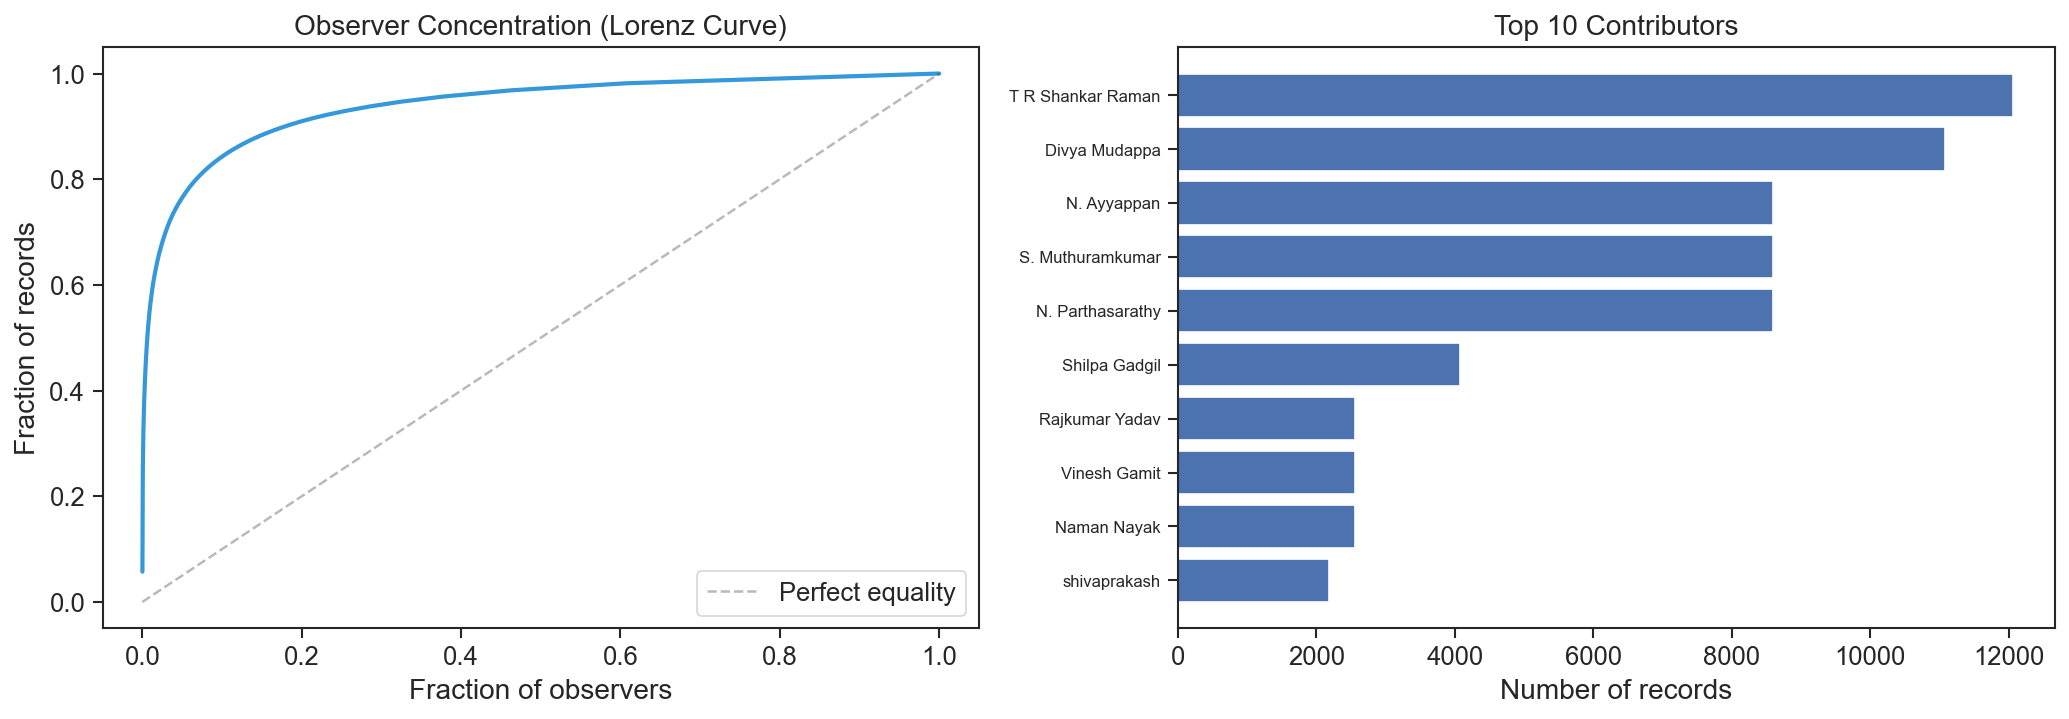

Unique observers: 9,878
Top 10 contributors account for 29.9% of records
Top 1% of contributors account for 56.2% of records


In [21]:
# Figure 9: Observer concentration
# recordedby is a list column; load it separately
india_observers = (
    dd.read_parquet(PARQUET_PATH, columns=["countrycode", "recordedby"])
    .query("countrycode == 'IN'")
    .compute()
)

# Flatten list of observers to get individual contributor counts
observer_flat = india_observers.explode("recordedby").dropna(subset=["recordedby"])
observer_counts = observer_flat["recordedby"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lorenz curve
sorted_obs = observer_counts.sort_values(ascending=False).values
cumulative = np.cumsum(sorted_obs) / sorted_obs.sum()
n_observers = len(sorted_obs)
x = np.arange(1, n_observers + 1) / n_observers

axes[0].plot(x, cumulative, color="#3498db", linewidth=2)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Perfect equality")
axes[0].set_xlabel("Fraction of observers")
axes[0].set_ylabel("Fraction of records")
axes[0].set_title("Observer Concentration (Lorenz Curve)")
axes[0].legend()

# Top 10 observers
top10_obs = observer_counts.head(10)
labels = [str(x)[:30] for x in top10_obs.index[::-1]]
axes[1].barh(range(10), top10_obs.values[::-1])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(labels, fontsize=8)
axes[1].set_xlabel("Number of records")
axes[1].set_title("Top 10 Contributors")

plt.tight_layout()
plt.show()

top10_pct = top10_obs.sum() / observer_flat.shape[0]
top1pct_idx = max(1, int(n_observers * 0.01)) - 1
print(f"Unique observers: {n_observers:,}")
print(f"Top 10 contributors account for {top10_pct:.1%} of records")
print(f"Top 1% of contributors account for {cumulative[top1pct_idx]:.1%} of records")

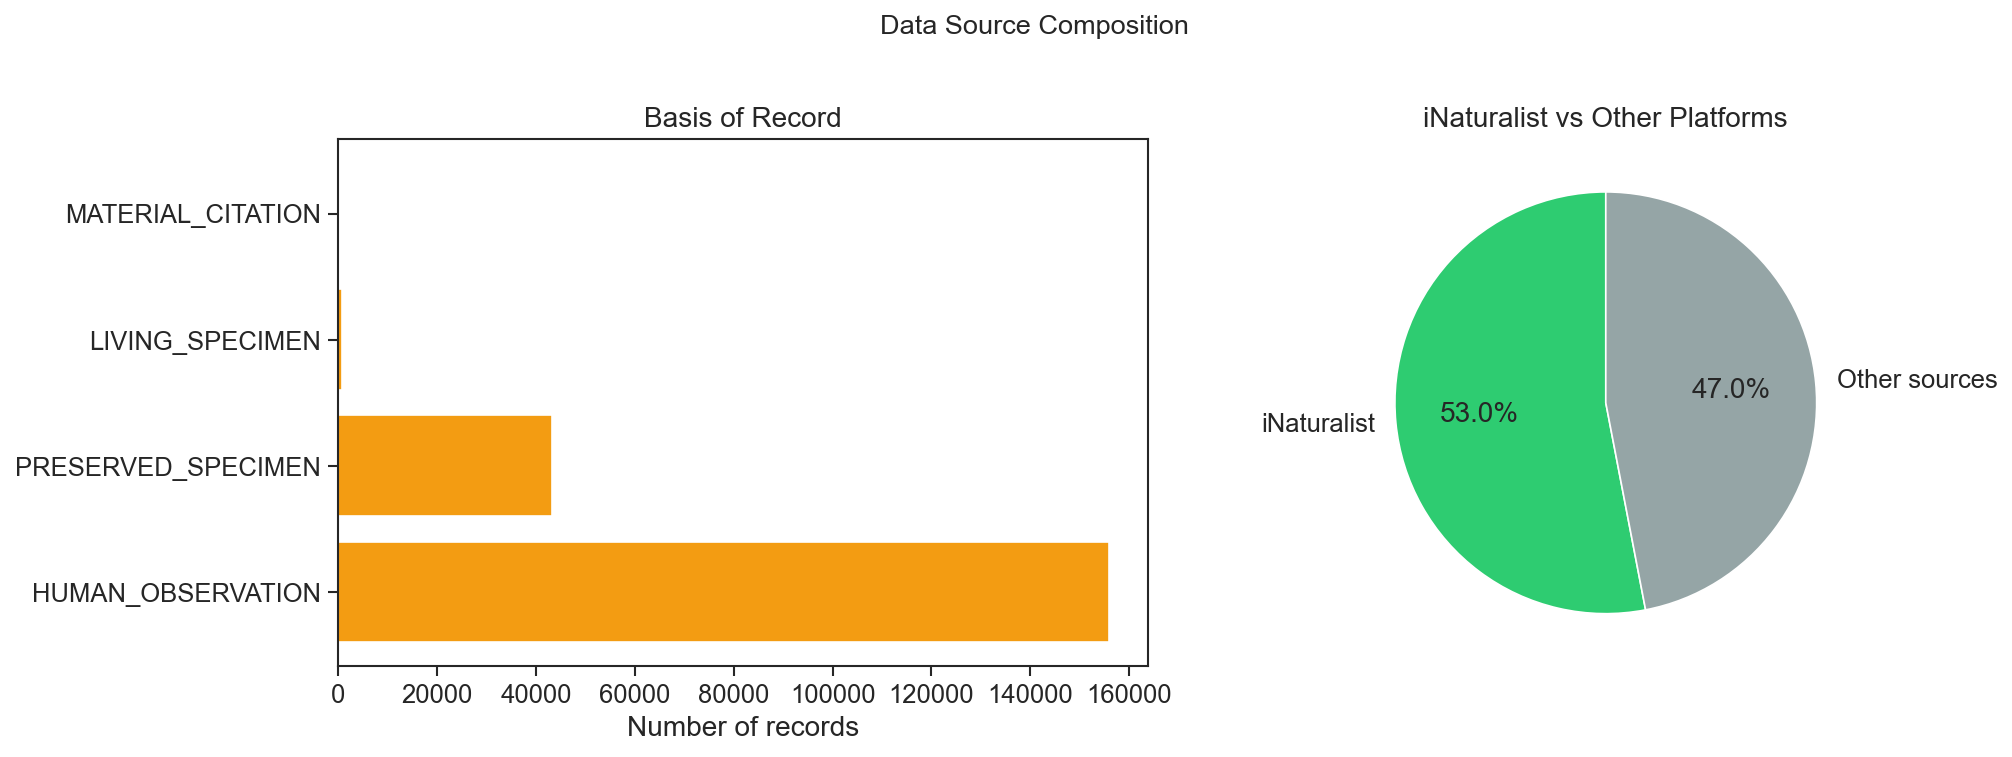

In [22]:
# Figure 10: Data source composition
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Basis of record
bor_counts = india_df.basisofrecord.value_counts()
axes[0].barh(bor_counts.index, bor_counts.values, color="#f39c12")
axes[0].set_title("Basis of Record")
axes[0].set_xlabel("Number of records")

# iNaturalist vs others
is_inat = india_df.datasetkey == INAT_DATASET_KEY
platform_counts = pd.Series(
    {"iNaturalist": is_inat.sum(), "Other sources": (~is_inat).sum()}
)
axes[1].pie(
    platform_counts,
    labels=platform_counts.index,
    autopct="%1.1f%%",
    colors=["#2ecc71", "#95a5a6"],
    startangle=90,
)
axes[1].set_title("iNaturalist vs Other Platforms")

fig.suptitle("Data Source Composition", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

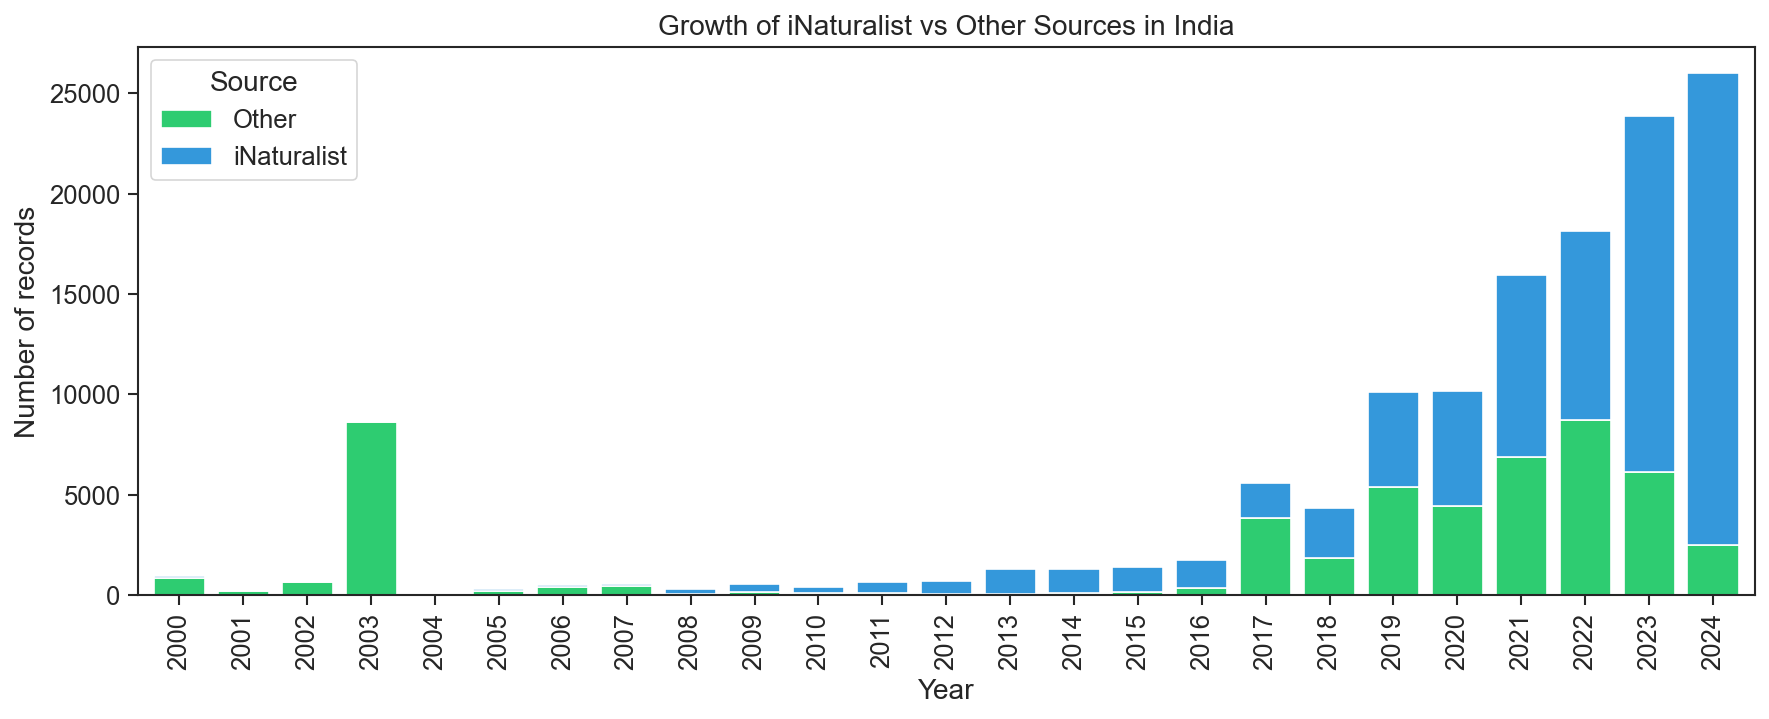

In [23]:
# Figure 11: iNaturalist vs other sources over time
india_df = india_df.assign(
    source=np.where(india_df.datasetkey == INAT_DATASET_KEY, "iNaturalist", "Other")
)

yearly_source = (
    india_df.dropna(subset=["year"])
    .query("2000 <= year <= 2024")
    .assign(year=lambda x: x.year.astype(int))
    .groupby(["year", "source"])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 5))
yearly_source.plot.bar(stacked=True, ax=ax, color=["#2ecc71", "#3498db"], width=0.8)
ax.set_xlabel("Year")
ax.set_ylabel("Number of records")
ax.set_title("Growth of iNaturalist vs Other Sources in India")
ax.legend(title="Source")
plt.tight_layout()
plt.show()

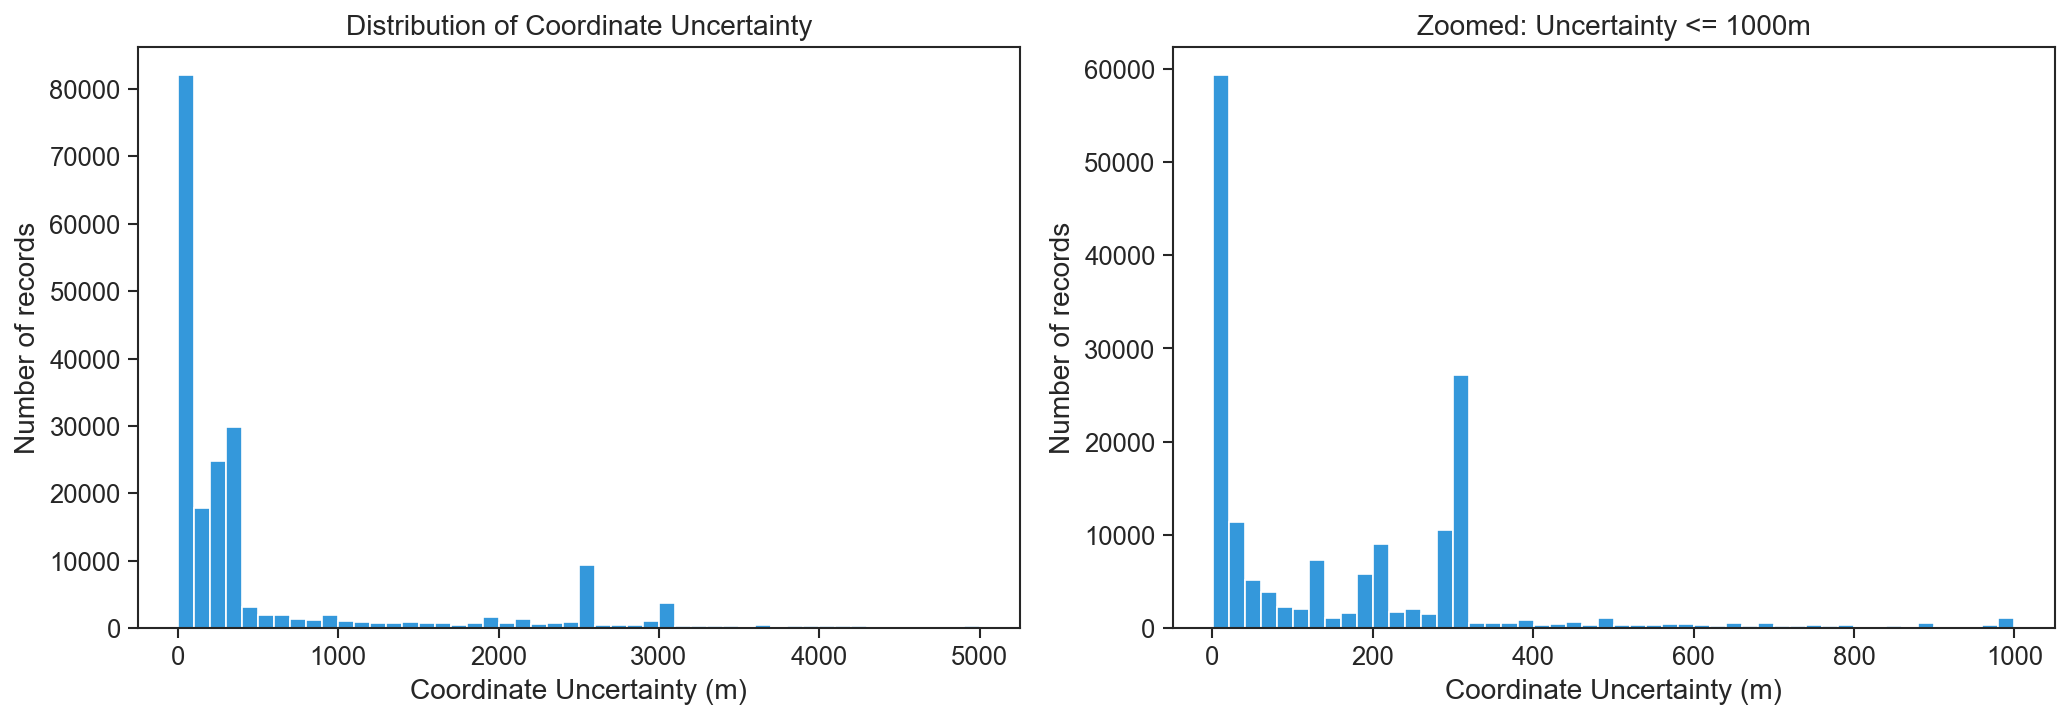

Records with uncertainty data: 200,175 (100.0%)
Median uncertainty: 201 m
Records with uncertainty <= 100m: 82,104 (41.0%)


In [24]:
# Figure 12: Coordinate uncertainty
uncertainty = india_df.coordinateuncertaintyinmeters.dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(uncertainty, bins=50, color="#3498db", edgecolor="white")
axes[0].set_xlabel("Coordinate Uncertainty (m)")
axes[0].set_ylabel("Number of records")
axes[0].set_title("Distribution of Coordinate Uncertainty")

axes[1].hist(
    uncertainty[uncertainty <= 1000], bins=50, color="#3498db", edgecolor="white"
)
axes[1].set_xlabel("Coordinate Uncertainty (m)")
axes[1].set_ylabel("Number of records")
axes[1].set_title("Zoomed: Uncertainty <= 1000m")

plt.tight_layout()
plt.show()

print(f"Records with uncertainty data: {len(uncertainty):,} ({len(uncertainty)/len(india_df):.1%})")
print(f"Median uncertainty: {uncertainty.median():.0f} m")
print(f"Records with uncertainty <= 100m: {(uncertainty <= 100).sum():,} ({(uncertainty <= 100).mean():.1%})")

## 5. Growth Trajectory and Projection

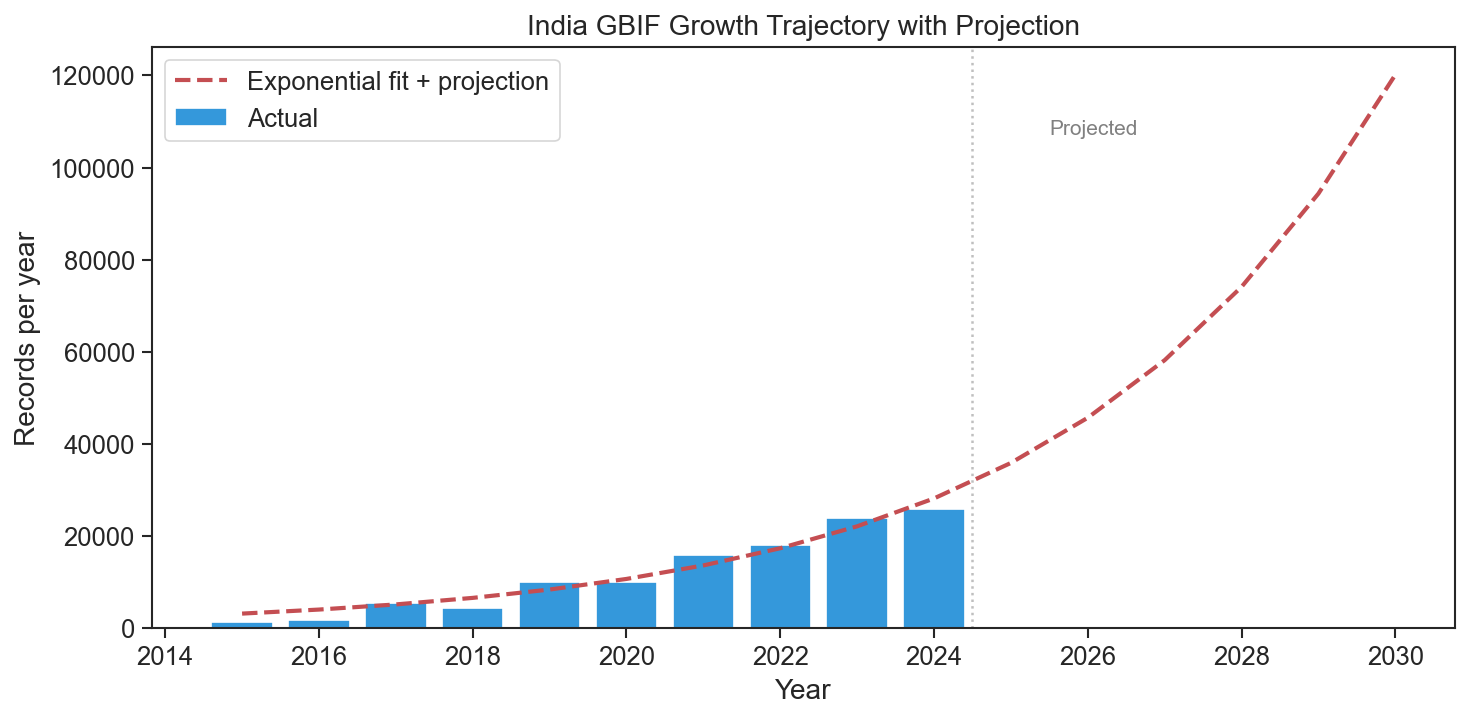

Fitted annual growth rate: 24.2%
Projected records in 2030: ~120,122


In [25]:
# Figure 13: Exponential growth fit with projection
yearly = (
    india_df.dropna(subset=["year"])
    .query("2015 <= year <= 2024")
    .groupby("year")
    .size()
)
yearly.index = yearly.index.astype(int)


def exp_growth(x, a, b):
    return a * np.exp(b * (x - 2015))


popt, pcov = curve_fit(exp_growth, yearly.index, yearly.values, p0=[1000, 0.3])
future_years = np.arange(2015, 2031)
projected = exp_growth(future_years, *popt)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(yearly.index, yearly.values, color="#3498db", label="Actual", zorder=2)
ax.plot(
    future_years, projected, "r--", linewidth=2,
    label="Exponential fit + projection", zorder=3,
)
ax.axvline(x=2024.5, color="gray", linestyle=":", alpha=0.5)
ax.text(2025.5, ax.get_ylim()[1] * 0.85, "Projected", fontsize=10, color="gray")
ax.set_xlabel("Year")
ax.set_ylabel("Records per year")
ax.set_title("India GBIF Growth Trajectory with Projection")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(f"Fitted annual growth rate: {popt[1]:.1%}")
print(f"Projected records in 2030: ~{exp_growth(2030, *popt):,.0f}")

## 6. Connection to Trait Mapping

Our published research (*Lusk et al., Nature Communications 2026*) shows that crowdsourced observations enable global-scale plant trait mapping. Here we examine how India's GBIF data contributes to this effort.

In [27]:
# Check how many Indian species have trait data
# Load the filtered GBIF data (species that matched TRY traits)
filtered_species = set(
    pd.read_parquet(
        "../data/interim/gbif/filtered_occurrences/try6/gbif_filtered.parquet",
        columns=["specieskey"],
    )
    .specieskey.astype(str)
    .unique()
)

india_species_all = india_df.query("taxonrank == 'SPECIES'").specieskey.unique()
india_species_set = set(str(s) for s in india_species_all)
matched = india_species_set & filtered_species

print(f"Unique species observed in India: {len(india_species_set):,}")
print(f"Species with TRY trait data (used in our study): {len(matched):,} ({len(matched)/len(india_species_set):.1%})")
print(f"Species WITHOUT trait data: {len(india_species_set) - len(matched):,}")
print(f"\nThese {len(matched):,} species with trait data enable India-specific")
print(f"trait map generation from citizen science observations.")

Unique species observed in India: 8,113
Species with TRY trait data (used in our study): 3,758 (46.3%)
Species WITHOUT trait data: 4,355

These 3,758 species with trait data enable India-specific
trait map generation from citizen science observations.


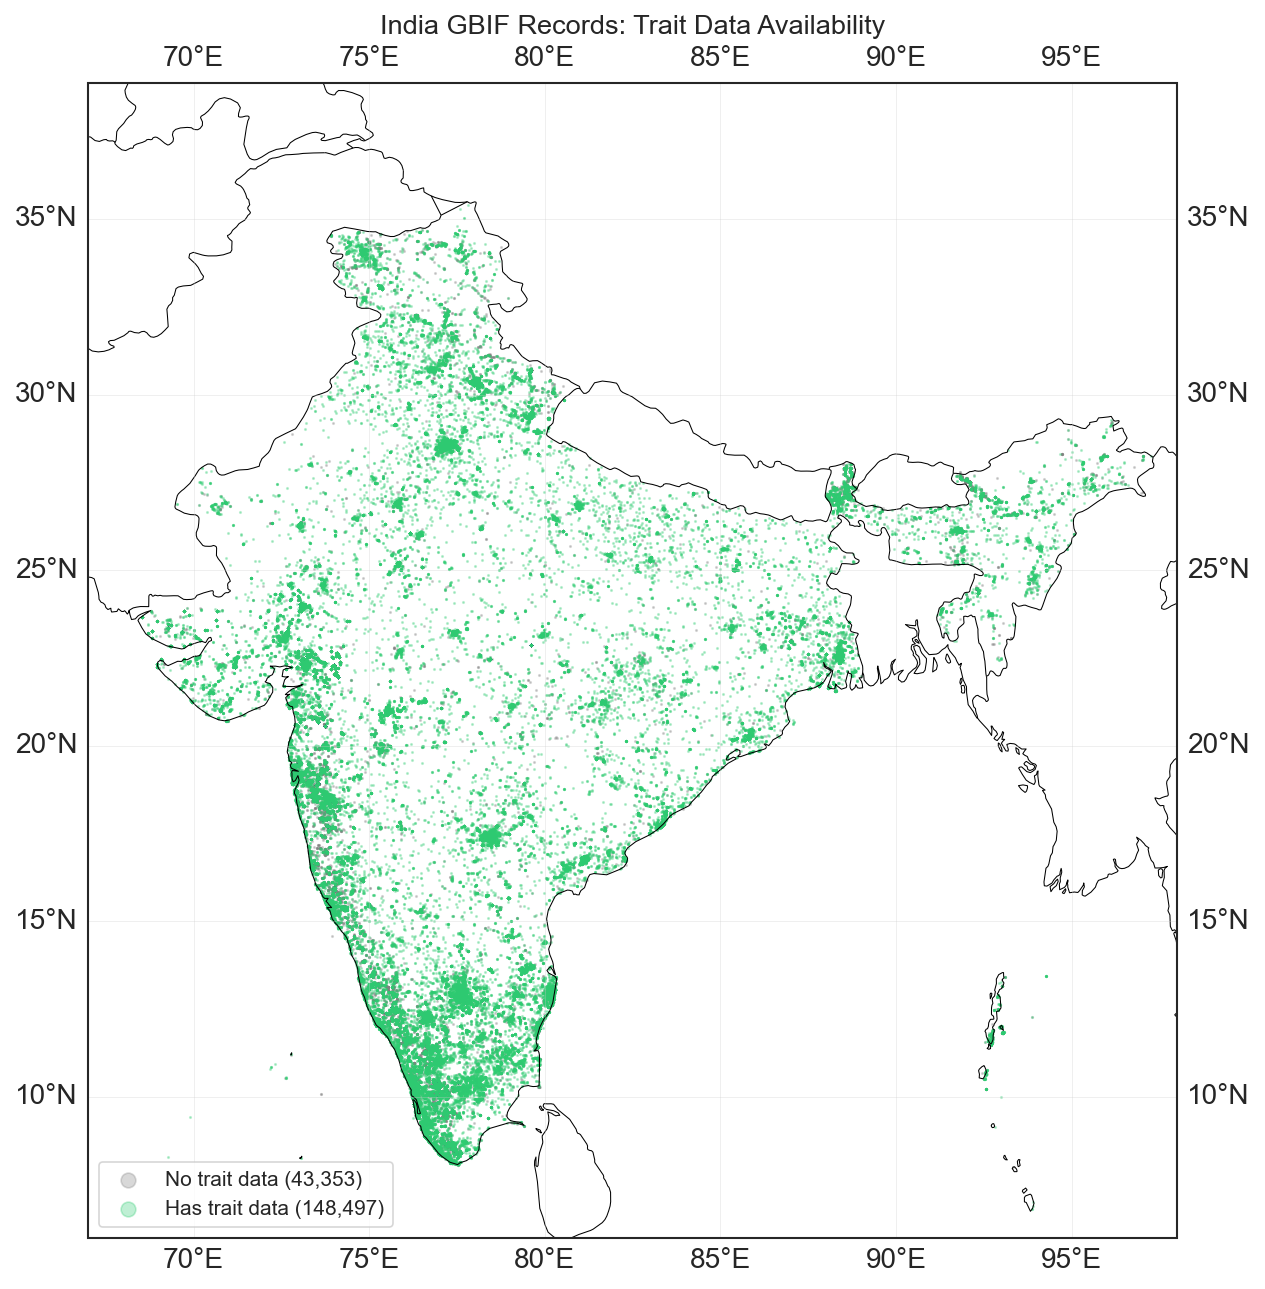

In [28]:
# Figure 14: Map of India colored by trait availability
india_sp_df = india_df.query("taxonrank == 'SPECIES'").copy()
india_sp_df["has_traits"] = india_sp_df.specieskey.astype(str).isin(matched)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([67, 98, 6, 38])
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

no_trait = india_sp_df.query("has_traits == False")
with_trait = india_sp_df.query("has_traits == True")

ax.scatter(
    no_trait.decimallongitude, no_trait.decimallatitude,
    s=0.5, alpha=0.3, c="gray",
    label=f"No trait data ({len(no_trait):,})",
    transform=ccrs.PlateCarree(),
)
ax.scatter(
    with_trait.decimallongitude, with_trait.decimallatitude,
    s=0.5, alpha=0.3, c="#2ecc71",
    label=f"Has trait data ({len(with_trait):,})",
    transform=ccrs.PlateCarree(),
)

ax.legend(markerscale=10, fontsize=10, loc="lower left")
ax.set_title("India GBIF Records: Trait Data Availability", fontsize=13)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
plt.show()

## 7. Summary

In [29]:
is_inat = india_df.datasetkey == INAT_DATASET_KEY

print("=" * 60)
print("SUMMARY: India's Contribution to GBIF Citizen Science")
print("=" * 60)
print()
print(f"Total India records: {len(india_df):,}")
print(f"Global share: {len(india_df) / total_global:.2%}")
print(f"Unique species: {india_df.species.nunique():,}")
print()
print("--- Normalization ---")
print(f"Per million people: {india_row.records_per_million_pop:,.0f}")
print(f"Per million km²: {india_row.records_per_mkm2:,.0f}")
print(f"Per known species: {india_row.records_per_species:,.1f}")
print()
print("--- Key biases ---")
print(f"iNaturalist share: {is_inat.mean():.1%}")
print(f"Human observation share: {(india_df.basisofrecord == 'HUMAN_OBSERVATION').mean():.1%}")
print(f"Top state: {state_counts.index[0]} ({state_counts.n_records.iloc[0]:,} records)")
print()
print("--- Growth ---")
recent_years = (
    india_df.dropna(subset=["year"])
    .query("2020 <= year <= 2024")
    .assign(year=lambda x: x.year.astype(int))
    .groupby("year")
    .size()
)
if len(recent_years) > 0:
    print(f"Records in most recent full year (2024): ~{recent_years.get(2024, 'N/A'):,}")
    print(f"Fastest growth period: last 5 years")

SUMMARY: India's Contribution to GBIF Citizen Science

Total India records: 200,175
Global share: 0.06%
Unique species: 8,148

--- Normalization ---
Per million people: 140
Per million km²: 60,899
Per known species: 11.1

--- Key biases ---
iNaturalist share: 53.0%
Human observation share: 77.9%
Top state: Tamil Nadu (27,194 records)

--- Growth ---
Records in most recent full year (2024): ~25,995
Fastest growth period: last 5 years
